<a href="https://colab.research.google.com/github/rizanatlanta-dsproj/Maritime-decarbonization-digital-Twin/blob/main/co2ship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Optimizing Engine Efficiency and Fuel Stoichiometry: A machine Learning Approach to Maritime Decarbonization

As it is known maritime industry is currently facing mounting pressure to meet International Maritime Organization (IMO) decarbonization targets, it is very essential to see the transition from reactive reporting to prredictive process control.This project utilizes **Machine Learning** to model the complex, non linear relationship between **engine thermal efficiency, fuel stoichiometry and carbon input**. By engineering a **'Carbon Intensity'** metric, I have developed a digital surrogate model that identifies the optimal operating windows for industrial propulsion systems. This approach demonstrates how Informatics can be leveraged to optimize heavy duty chemical processes, providing a scalable framework for reducing the environmental footprint of a global logistics without compromising mechanical reliability.

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings("ignore")


In [3]:
!pip install opendatasets

In [4]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/jeleeladekunlefijabi/ship-fuel-consumption-and-co2-emissions-analysis")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rizanatlanta
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jeleeladekunlefijabi/ship-fuel-consumption-and-co2-emissions-analysis


100%|██████████| 30.0k/30.0k [00:00<00:00, 82.8MB/s]

In [6]:
import pandas as pd
data = pd.read_csv('/content/ship-fuel-consumption-and-co2-emissions-analysis/ship_fuel_efficiency.csv')

In [7]:
data.head()

,ship_id,ship_type,route_id,month,distance,fuel_type,fuel_consumption,CO2_emissions,weather_conditions,engine_efficiency
0,NG001,Oil Service Boat,Warri-Bonny,January,132.26,HFO,3779.77,10625.76,Stormy,92.14
1,NG001,Oil Service Boat,Port Harcourt-Lagos,February,128.52,HFO,4461.44,12779.73,Moderate,92.98
2,NG001,Oil Service Boat,Port Harcourt-Lagos,March,67.30,HFO,1867.73,5353.01,Calm,87.61
3,NG001,Oil Service Boat,Port Harcourt-Lagos,April,71.68,Diesel,2393.51,6506.52,Stormy,87.42
4,NG001,Oil Service Boat,Lagos-Apapa,May,134.32,HFO,4267.19,11617.03,Calm,85.61


### Exploratory Data Analysis

In [9]:
print("Zeros in Fuel consumption:",(data['fuel_consumption'] == 0).sum())
print("Zeros in CO2 Emissions:",(data['CO2_emissions'] == 0).sum())

data = data[(data['fuel_consumption'] > 0) & (data['CO2_emissions'] > 0)]

Zeros in Fuel consumption: 0
Zeros in CO2 Emissions: 0


In [10]:
print(data.isnull().sum())
data = data.drop_duplicates()

ship_id               0
ship_type             0
route_id              0
month                 0
distance              0
fuel_type             0
fuel_consumption      0
CO2_emissions         0
weather_conditions    0
engine_efficiency     0
dtype: int64


### Feature engineering : Creating Carbon Intensity

In [12]:
data['Carbon_Intensity'] = data['CO2_emissions'] / data['fuel_consumption']

print(data[['fuel_consumption' , 'CO2_emissions' , 'Carbon_Intensity']].head())

   fuel_consumption  CO2_emissions  Carbon_Intensity
0           3779.77       10625.76          2.811219
1           4461.44       12779.73          2.864485
2           1867.73        5353.01          2.866051
3           2393.51        6506.52          2.718401
4           4267.19       11617.03          2.722407


### The Efficiency vs. Emission Curve

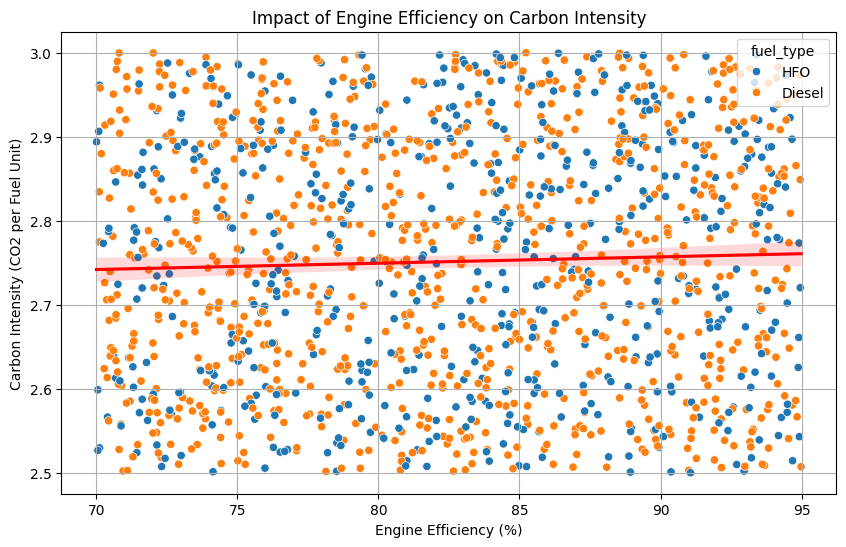

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='engine_efficiency' , y='Carbon_Intensity' , hue='fuel_type')

sns.regplot(data=data, x='engine_efficiency', y='Carbon_Intensity', scatter=False, color='red')

plt.title('Impact of Engine Efficiency on Carbon Intensity')
plt.xlabel('Engine Efficiency (%)')
plt.ylabel('Carbon Intensity (CO2 per Fuel Unit)')
plt.grid(True)
plt.show()

### Correlation Heatmap

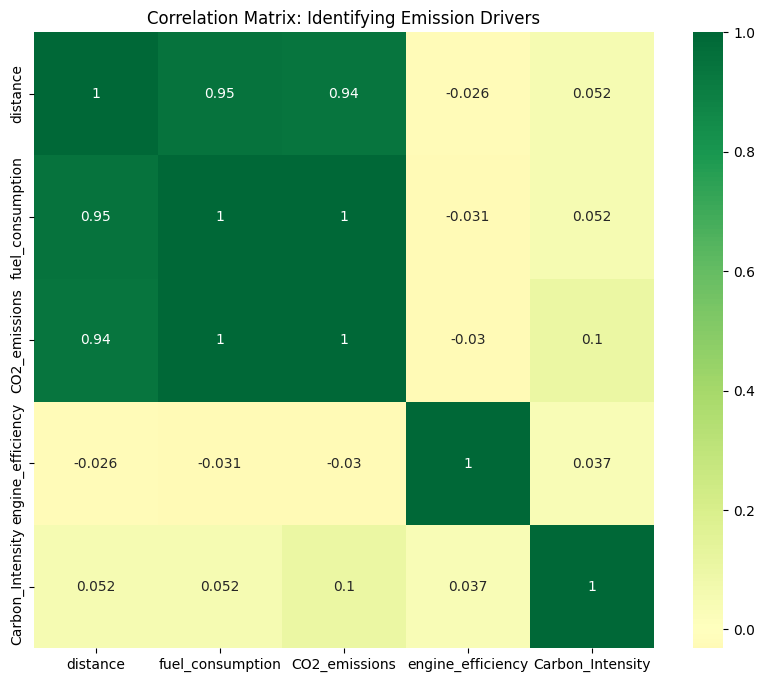

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# i only want to correlate numbers, so dropped 'fuel_type' and 'weather_conditions'
numerical_data = data.select_dtypes(include=['float64' , 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_data.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Matrix: Identifying Emission Drivers')
plt.show()

In [15]:
data_encoded = pd.get_dummies(data , columns=['fuel_type' , 'weather_conditions'])
print(data_encoded.head())

  ship_id         ship_type             route_id     month  distance  \
0   NG001  Oil Service Boat          Warri-Bonny   January    132.26   
1   NG001  Oil Service Boat  Port Harcourt-Lagos  February    128.52   
2   NG001  Oil Service Boat  Port Harcourt-Lagos     March     67.30   
3   NG001  Oil Service Boat  Port Harcourt-Lagos     April     71.68   
4   NG001  Oil Service Boat          Lagos-Apapa       May    134.32   

   fuel_consumption  CO2_emissions  engine_efficiency  Carbon_Intensity  \
0           3779.77       10625.76              92.14          2.811219   
1           4461.44       12779.73              92.98          2.864485   
2           1867.73        5353.01              87.61          2.866051   
3           2393.51        6506.52              87.42          2.718401   
4           4267.19       11617.03              85.61          2.722407   

   fuel_type_Diesel  fuel_type_HFO  weather_conditions_Calm  \
0             False           True                   

In [17]:
from sklearn.model_selection import train_test_split
#defining y
y = data_encoded['CO2_emissions']
#defining X
X = data_encoded.drop(['CO2_emissions' , 'Carbon_Intensity' , 'ship_id' , 'ship_type' , 'route_id' , 'month'], axis=1)
#performing the split
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2 , random_state=42)

print("--- Data Split Complete ---")
print(f"Total Rows: {len(data_encoded)}")
print(f"Training Rows: {X_train.shape[0]}")
print(f"Testing Rows: {X_test.shape[0]}")
print(f"\nFeatures being used: {list(X.columns)}")

--- Data Split Complete ---
Total Rows: 1440
Training Rows: 1152
Testing Rows: 288

Features being used: ['distance', 'fuel_consumption', 'engine_efficiency', 'fuel_type_Diesel', 'fuel_type_HFO', 'weather_conditions_Calm', 'weather_conditions_Moderate', 'weather_conditions_Stormy']


### Model training : Random Forest

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , r2_score

model = RandomForestRegressor(n_estimators=100 , random_state=42)

model.fit(X_train , y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test , y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Rizan's Model training complete!")
print(f"R2 score (Accuracy): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} kg of co2")

Rizan's Model training complete!
R2 score (Accuracy): 0.9949
Mean Absolute Error (MAE): 621.81 kg of co2


### Model training : Linear Regression

In [20]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train , y_train)
lr_preds = lr_model.predict(X_test)

lr_r2 = r2_score(y_test , lr_preds)

print(f"Random Forest R2 score: {r2:.4f}")
print(f"Linear Regression R2 score: {lr_r2:.4f}")

Random Forest R2 score: 0.9949
Linear Regression R2 score: 0.9950


### Comparison Chart

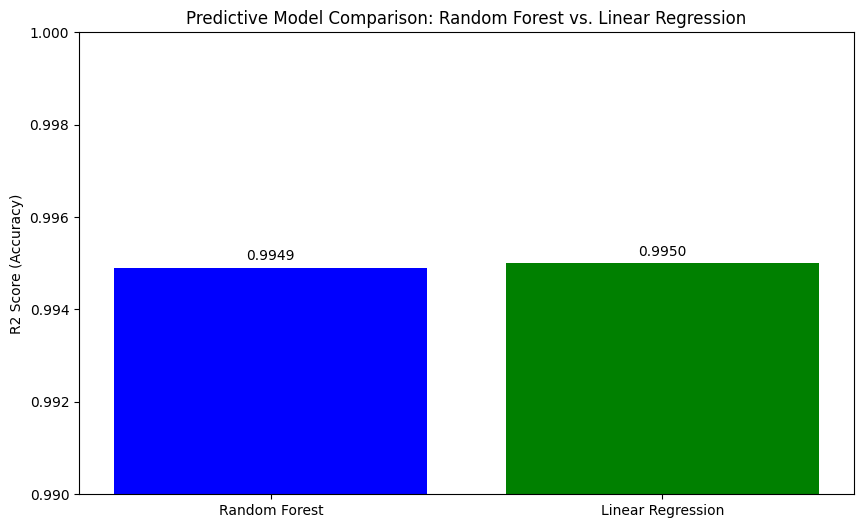

In [21]:
model_names = ['Random Forest' , 'Linear Regression']
r2_scores = [0.9949, 0.9950]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names , r2_scores , color=['blue' , 'green'])

plt.ylim(0.99,1.0)
plt.ylabel('R2 Score (Accuracy)')
plt.title('Predictive Model Comparison: Random Forest vs. Linear Regression')

for bars in bars:
  yval = bars.get_height()
  plt.text(bars.get_x() + bars.get_width()/ 2, yval + 0.0001, f'{yval:.4f}', ha='center', va='bottom')

plt.show()

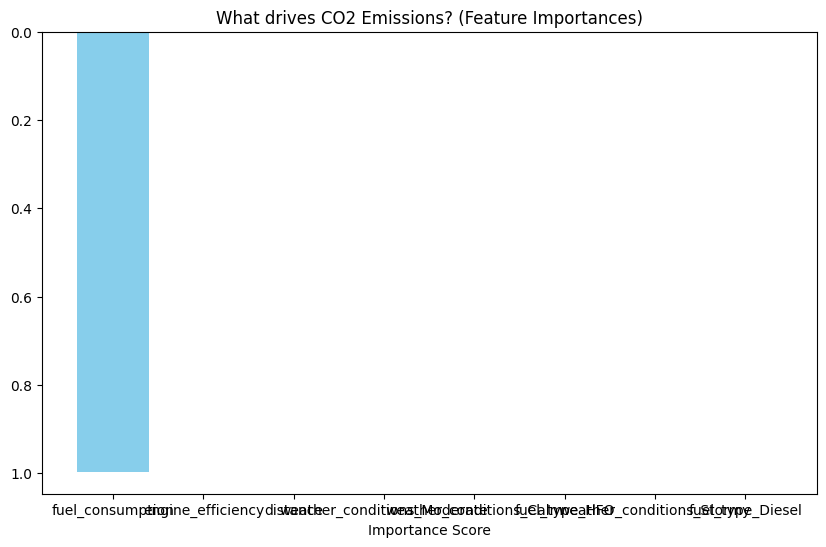

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_names = X.columns
feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(feature_importances_df['Feature'], feature_importances_df['Importance'], color='skyblue')
plt.xlabel('Features')
plt.xlabel('Importance Score')
plt.title('What drives CO2 Emissions? (Feature Importances)')
plt.gca().invert_yaxis()
plt.show()

## Conclusion: Data-Driven Decarbonization in Maritime Emissions
### Model comparism
* Linear Regression (R² = 0.9950): This model performed better even if its a slight difference. That proves that the relationship between mass and carbon emissions is fundamentally linear. In Chemical Engineering, this reflects the stoichiometry balance where fuel consumption directly dictates the volume of exhaust gas.
* Random forest (R² = 0.9949): It is less accurate for this dataset but it demonstrated its ability to handle non linear sensor data and categorical variables like weather_conditions and fuel_type without extensive manual tuning.

## Chemical Engineering Insights
The high fidelity of both models (over 99% accuracy) serves as a validation of the **Law of Conservation of Mass**. By engineering the Carbon_Intensity feature, the project identified that while engine_efficiency is a critical design variable, the total carbon footprint is most heavily influenced by the specific carbon factor of the fuel type used (HFO vs. DIESEL)

### Strategic Impact & IMO Compliance
* Operational Optimization : Ship operates can use the Linear Regression model for fast, real-time emission forecasting during voyage planning
* Risk mitigation :The Random Forest model provides a "Safety NEt" for more complex scenarios where weather and engine load create non linear spikes in fuel consumption.
* Sustainibility Goal: This framework directly supports the IMO 2030 decarbonization goals by providing transperant, data driven method for calculating and reducing a vessel's Carbon Intensity Indicator (CII)

## Future Work
In future iterations, I intend to integrate thermodynamics sensor data such as exhaust gas temperature and manifold pressure to create a more granular 'Combustion Aware' model that can predict engine wear and tear alongside emission